# FEM Elements

## Finite-elements space of $H_0^1(0,1)$ with piece-wise linear functions 

In [1]:
using BandedMatrices, DifferentialEquations, Plots, LaTeXStrings

## Heat equation
$$
    \frac{\partial u}{\partial t} -\frac{\partial^2 u}{\partial x^2} = 0 \text{ in } (0,1) \times (0,\infty) \qquad u(0,t) = u(1,t) = 0 \qquad u(x,0) = u_0(x)
$$

In [3]:
function stiffness_matrix_piecewise_linear_Dirichlet(x::Vector)::BandedMatrix
    N = length(x) - 1
    # mass_upper_diag[i] = \int_{x_0}^{x_N} \phi_i' \phi_{i+1}'
    upper_diag = [-1 / (x[i+1] - x[i]) for i = 2:N-1]

    # mass_diag[i] = \int_{x_0}^{x_N} (\phi_i')^2
    diag = [1 / (x[i+1] - x[i]) + 1 / (x[i+2] - x[i+1]) for i = 1:N-1]

    K = BandedMatrix{Float64}(undef, (N - 1, N - 1), (1, 1))
    K[band(0)] = diag
    K[band(1)] = upper_diag
    K[band(-1)] = upper_diag
    return K
end

K = stiffness_matrix_piecewise_linear_Dirichlet(x)

3×3 BandedMatrix{Float64} with bandwidths (1, 1):
  12.0  -10.0    ⋅ 
 -10.0   15.0  -5.0
    ⋅    -5.0  10.0

In [6]:
"""
Gaussian integral with two points
"""
function integral2(P, a, b)
    Q(y) = P((b - a) / 2 * y + (a + b) / 2)
    return (b - a) / 2 * (Q(-1 / sqrt(3)) + Q(1 / sqrt(3)))
end;

In [7]:
using Test
@testset begin 
    @test integral2(x->1., 0, 1) ≈ 1
    @test integral2(x->x, 0, 1) ≈ 1/2
    @test integral2(x->x^2, 0, 1) ≈ 1/3
    @test integral2(x->x^3, 0, 1) ≈ 1/4
end

Test Summary: | Pass  Total  Time
test set      |    4      4  0.2s


Test.DefaultTestSet("test set", Any[], 4, false, false, true, 1.753714340606367e9, 1.753714340783172e9, false, "/Users/david/Overleaf/master-mnu/lectures/finite-elements/d-1/linear/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl")

In [8]:
function mass_matrix_piecewise_linear_Dirichlet(x::Vector)::BandedMatrix
    N = length(x) - 1
    upper_diag = zeros(N - 2) # upper_diag[i] = \int_{x_0}^{x_N} \phi_i \phi_{i+1}
    for i = 1:N-2
        a = x[i+1]
        b = x[i+2]
        P(x) = (x - a) * (b - x) / ((b - a)^2)
        upper_diag[i] = integral2(P, a, b)
    end

    diag = zeros(N - 1) # diag[i] = \int_{x_0}^{x_N} \phi_{i}^2
    for i = 1:N-1
        a = x[i]
        b = x[i+1]
        P(x) = (x - a)^2 / ((b - a)^2)
        I1 = integral2(P, a, b)

        a = x[i+1]
        b = x[i+2]
        P(x) = (b - x)^2 / ((b - a)^2)
        I2 = integral2(P, a, b)

        diag[i] = I1 + I2
    end

    M = BandedMatrix{Float64}(undef, (N - 1, N - 1), (1, 1))
    M[band(0)] = diag
    M[band(1)] = upper_diag
    M[band(-1)] = upper_diag
    return M
end

mass_matrix_piecewise_linear_Dirichlet (generic function with 1 method)

In [9]:
x = collect(0:2.0^-3:1)
u0(x) = x^2*sin(π*x)
U0 = [u0(x[i]) for i = 2:length(x)-1];

┌ Info: Saved animation to /var/folders/xw/gsxl4qb95jbbrw90lp6stm7h0000gn/T/jl_tEhO3ER8JI.gif
└ @ Plots /Users/david/.julia/packages/Plots/3u4B6/src/animation.jl:156


Plots.AnimatedGif("/var/folders/xw/gsxl4qb95jbbrw90lp6stm7h0000gn/T/jl_tEhO3ER8JI.gif")
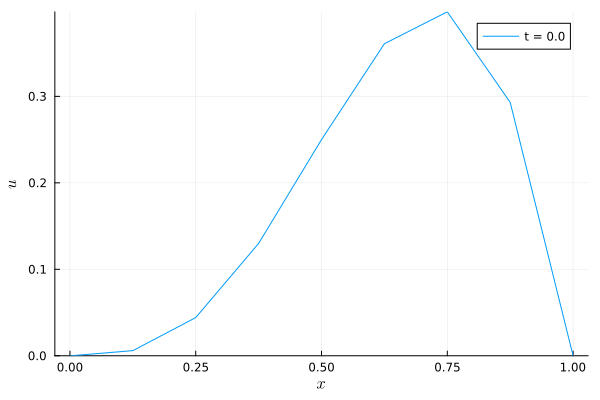

In [10]:

# M dU/dt + K*U = 0
M = mass_matrix_piecewise_linear_Dirichlet(x)
K = stiffness_matrix_piecewise_linear_Dirichlet(x)
f(U, p, t) = -M \ (K * U)
tspan = (0.0, 1.0)
prob = ODEProblem(f, U0, tspan)
sol = solve(prob)
@gif for (i,t) in enumerate(sol.t)
    plot(x, [0; sol.u[i]; 0], ylims = (0, maximum(U0)), label="t = $(round(t,digits=3))", xlabel=L"x", ylabel=L"u")
end